# M606 Machine Learning – Individual Project

**Name:** Nirjar Dipakbhai Baladha  
**Student ID:** GH1051918  
**Module:** M606 Machine Learning  
**Dataset:** Telco Customer Churn (IBM Sample Dataset)  
**Dataset URL:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn 

**Github repo:** https://github.com/Nirjxr/Customer_Churn-Machine-Learning

Problem Statement

Business Context

One of the most expensive issues of telecommunications companies is customer churn the rate of the subscribers to their service terminating. The industry studies point out that it is five to twenty-five times more expensive to acquire a new customer than an existing customer (Reichheld and Schefter, 2000). To a huge telecom company that has millions of subscribers, even a small increase in the accuracy of churn prediction can mean millions of euros of revenue saved every year.

Why This Problem Matters

The reactive system - acting after a customer has gone is in itself expensive and ineffective. An active, data-driven initiative focused on tracking at-risk customers prior to a churn will enable the business to make an intervention by offering customers specific retention incentives (e.g., contract upgrades, loyalty discounts, priority support). This transforms the company to an offensive retention plan to a defensive one.

Data Collection

The publicly available IBM Telco Customer Churn dataset is used in this project. Such data would be gathered in a real-life scenario out of: CRM systems (customer demographics and contract information), billing systems (monthly payments, payment options), and service usage logs (internet, phone, streaming services).

Formulation of Machine Learning.

This issue is posed as binary classification problem:
Target variable: Churn (Yes = customer left within the last month, No = customer stayed)
Attributes of input: 19 demographic, service-usage, and billing attributes.
Goal: Train a classifier that is used to predict whether any individual customer will churn, so that the retention team can focus on who they should reach out to.

The model should not be considered in isolation, since the and the imbalance between classes (non-churners and churners) and the asymmetry between the cost of false negative and false positive should be taken into account in general and not only with regard to the accuracy.

In [58]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as npy
import pandas as pds
import matplotlib.pyplot as mplt
import seaborn as snsb

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

snsb.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Data Exploration and Characteristics

### 2.1 Loading and Inspecting the Dataset

In [59]:
# Load the dataset
df_raws = pds.read_csv('Telco_Customer_Churn.csv')
print(f"Dataset shape: {df_raws.shape}")
df_raws.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [60]:
# Data types and basic info
df_raws.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [61]:
# Basic descriptive statistics for numerical columns
df_raws.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


2.2 Data Quality Issues

On inspection, a number of data quality problems were observed:

customerID: Unique identifier which is not predictive - need to be dropped.
TotalCharges: This Charge is numeric, but stored as a string/object. Quiet spaces lead to failures of pd.to_numeric conversions with NaN values of new customers whose tenure is zero.
SeniorCitizen: Forced as a 0/1 integer- no transformation.
Class imbalance: Churn is not balanced (approximately 26% churners and 74 non-churners), which makes the evaluation of the model and the choice of metrics.

In [62]:
# Fix TotalCharges: convert to numeric (spaces become NaN)
df = df_raws.copy()
df['TotalCharges'] = pds.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# These 11 rows are new customers (tenure=0) — drop them
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop customerID
df.drop(columns=['customerID'], inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"\nCleaned dataset shape: {df.shape}")

Missing values per column:
TotalCharges    11
dtype: int64

Cleaned dataset shape: (7032, 20)


Class distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.58%


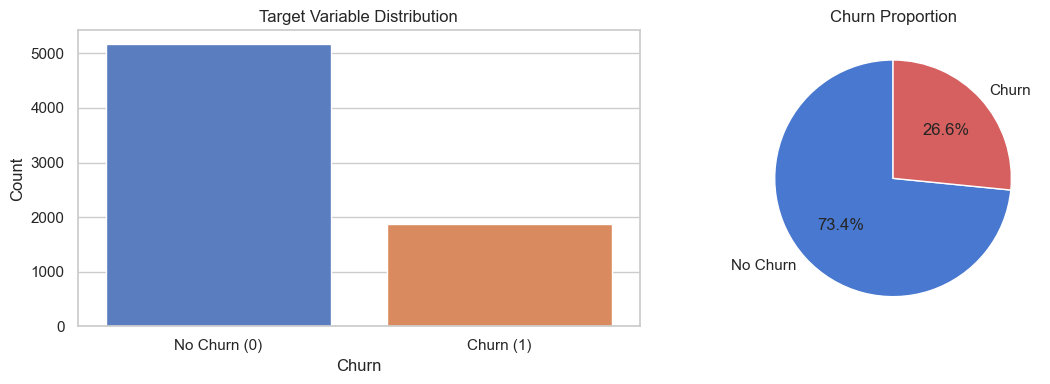


Discussion: The dataset is moderately imbalanced (~26% churners). 
This means accuracy alone is misleading — a model predicting 'No Churn' 
for every customer would achieve 74% accuracy without learning anything useful.
We will use ROC-AUC and F1-score (weighted) as primary evaluation metrics,
and stratified splits/cross-validation to preserve class proportions.


In [63]:
# Class distribution
churn_counts = df['Churn'].value_counts()
print("Class distribution:")
print(churn_counts)
print(f"\nChurn rate: {churn_counts[1] / len(df):.2%}")

fig, axes = mplt.subplots(1, 2, figsize=(12, 4))

# Count plot
snsb.countplot(x='Churn', data=df, palette='muted', ax=axes[0])
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#4878CF', '#D65F5F'], startangle=90)
axes[1].set_title('Churn Proportion')

mplt.tight_layout()
mplt.show()

print("""
Discussion: The dataset is moderately imbalanced (~26% churners). 
This means accuracy alone is misleading — a model predicting 'No Churn' 
for every customer would achieve 74% accuracy without learning anything useful.
We will use ROC-AUC and F1-score (weighted) as primary evaluation metrics,
and stratified splits/cross-validation to preserve class proportions.""")

### 2.3 Exploratory Data Analysis (EDA)

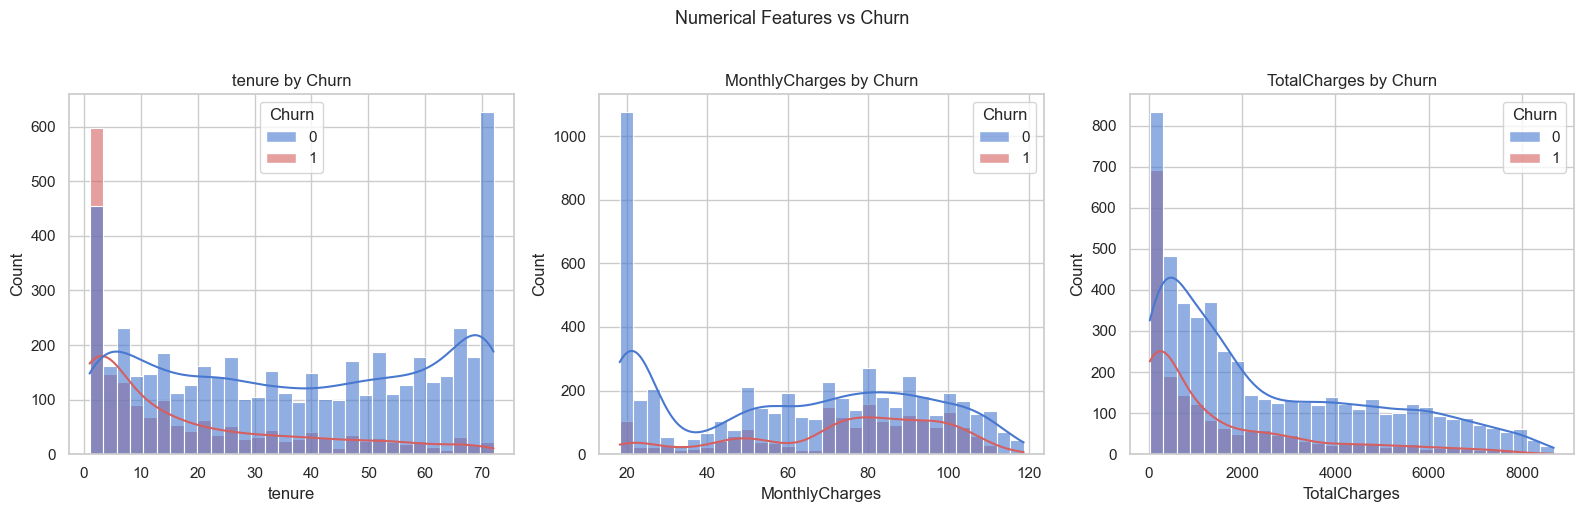

In [64]:
# Numerical feature distributions by churn
fig, axes = mplt.subplots(1, 3, figsize=(16, 5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for ax, col in zip(axes, num_cols):
    snsb.histplot(data=df, x=col, hue='Churn', kde=True, bins=30,
                 palette={0: '#4878CF', 1: '#D65F5F'}, ax=ax, alpha=0.6)
    ax.set_title(f'{col} by Churn')
mplt.suptitle('Numerical Features vs Churn', y=1.02, fontsize=13)
mplt.tight_layout()
mplt.show()

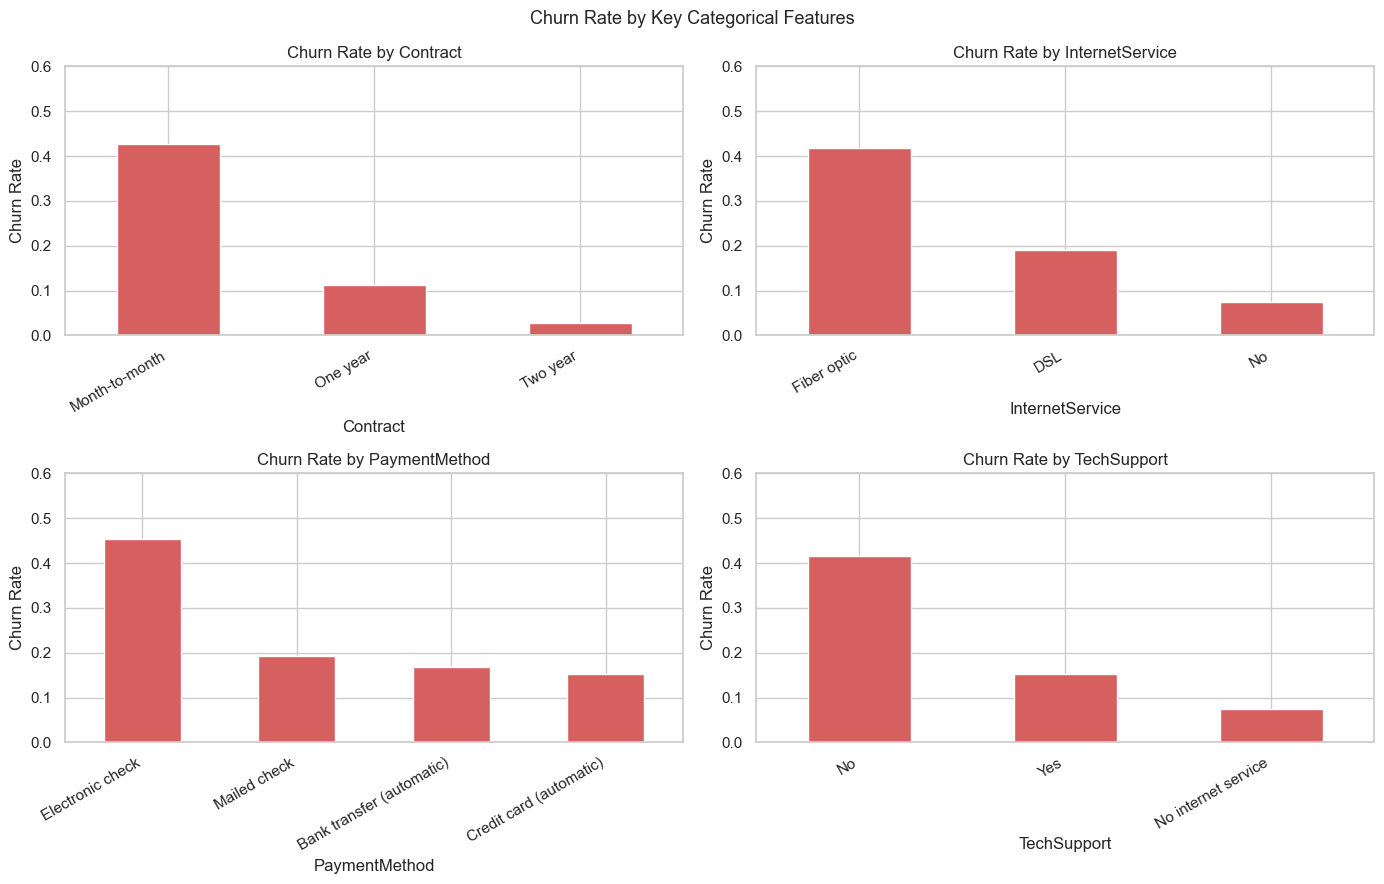

In [65]:
# Key categorical features vs Churn
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']
fig, axes = mplt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='#D65F5F', edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_ylim(0, 0.6)
mplt.suptitle('Churn Rate by Key Categorical Features', fontsize=13)
mplt.tight_layout()
mplt.show()

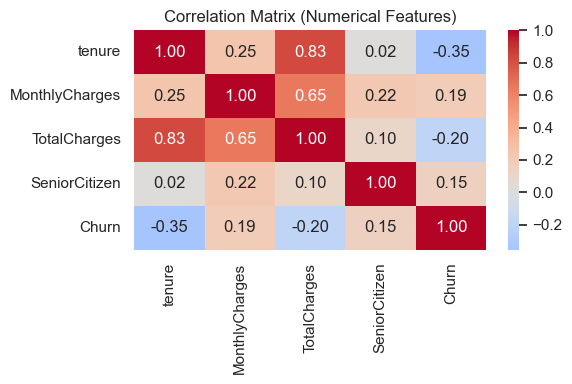


Key EDA Findings:
• Customers on Month-to-month contracts churn at ~43% vs ~11% for Two-year contracts.
• Fiber optic internet users churn significantly more than DSL users.
• Short-tenure customers (< 12 months) are the highest-risk group.
• Higher MonthlyCharges correlate with increased churn.
• Lack of TechSupport and OnlineSecurity strongly associates with churn.


In [66]:
# Correlation heatmap (numerical features only)
mplt.figure(figsize=(6, 4))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']].corr()
snsb.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
mplt.title('Correlation Matrix (Numerical Features)')
mplt.tight_layout()
mplt.show()

print("""
Key EDA Findings:
• Customers on Month-to-month contracts churn at ~43% vs ~11% for Two-year contracts.
• Fiber optic internet users churn significantly more than DSL users.
• Short-tenure customers (< 12 months) are the highest-risk group.
• Higher MonthlyCharges correlate with increased churn.
• Lack of TechSupport and OnlineSecurity strongly associates with churn.""")

Data Preparation Data Preprocessing and Data Engineering.

Why We’re Doing It This Way
The golden rule of machine learning is easy, do not look at the answers. In cleaning up or transforming our data, we must ensure that all our calculations (such as finding the average, scaling values) are only using the training set. In doing so, we leak data. It is similar to handing a student a practice exam that contains the real questions on the final- the student will do well in it, but hasn't really learned how to solve new problems.

We are employing sklearn.pipeline.Pipeline to keep ourselves honest. This tool is a self-enclosed assembly line, the fit occurs only on the training data and then these same rules are just replicated on the test data.

Our Strategy for Categories
You may be tempted to invoke pd.get_dummies, but this is dangerous as it acts on the whole dataset simultaneously, so it is a prime cause of leakage. Rather, we are just keeping OrdinalEncoder in our pipeline.

We are dealing with the various labels in the following way:

Yes/No Columns: These are mapped simply to 0 or 1.

Multi-choice Categories:Ordinal encoding is being used. Why? Since the tree-based models we are working with do not actually require that the numbers be in order, we only require them to be unique. In our case with Logistic Regression, it copes with these categories perfectly as long as we scale the data appropriately given that the size of our data is this large.

In [67]:
# ── Define feature sets ──────────────────────────────────────────────────────

# Binary Yes/No columns → map to 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
internet_binary = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'TechSupport', 'StreamingTV', 'StreamingMovies']

# Multi-category columns → OrdinalEncoder
multi_cols = ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']

# Numerical columns (pass through)
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

# Apply binary mapping manually (safe: no fit required for deterministic maps)
map_yes_no = {'Yes': 1, 'No': 0,
              'No phone service': 0, 'No internet service': 0}

df_proc = df.copy()
for col in binary_cols + internet_binary:
    df_proc[col] = df_proc[col].map(map_yes_no)

# Feature engineering: tenure groups (domain knowledge)
df_proc['tenure_group'] = pds.cut(df_proc['tenure'],
                                  bins=[0, 12, 24, 48, 72],
                                  labels=[0, 1, 2, 3]).astype(int)

# Define X and y
FEATURE_COLS = num_cols + binary_cols + internet_binary + multi_cols + ['tenure_group']
X = df_proc[FEATURE_COLS]
y = df_proc['Churn']

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True).round(3))

Feature matrix shape: (7032, 20)
Target distribution:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


In [68]:
# ── Train / Test Split (stratified, 80/20) ───────────────────────────────────
# IMPORTANT: split BEFORE any encoder fitting to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Test set      : {X_test.shape[0]} samples")
print(f"Train churn % : {y_train.mean():.2%}")
print(f"Test  churn % : {y_test.mean():.2%}")

Training set  : 5625 samples
Test set      : 1407 samples
Train churn % : 26.58%
Test  churn % : 26.58%


## 4. Hyperparameter Training of Models.

### Model Selection Strategy

Three candidate algorithms are tested:
1. **Logistic Regression** - a linear interpretable and computationally efficient baseline.
2. **Random Forest** - is a collection of decision trees that are effective in non-linear relationships and feature interactions.
3. **Gradient Boosting** - A sequential boosting ensemble which has been shown to perform well on tabular classification problems.

The models are implemented in a `Pipeline` with the addition of the OrdinalEncoder (to the multi-category columns) and StandardScaler. This guarantees that there is no data leakage: only the training fold is fitted to the encoder and scaler.

The hyperparameters are optimised using the `GridSearchCV` with 5-fold stratified cross-validation which optimises the ROC-AUC - a metric that is resistant to class imbalance and measures the capability of a model to rank churners higher than non-churners at all thresholds.

In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Columns needing OrdinalEncoder (multi-category strings)
ord_cols = multi_cols  # ['gender','MultipleLines','InternetService','Contract','PaymentMethod']
# All remaining features are already numeric
pass_cols = num_cols + binary_cols + internet_binary + ['tenure_group']

# Preprocessing sub-pipeline
preprocessor = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ord_cols),
    ('num', StandardScaler(), pass_cols)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = 'roc_auc'

print("Preprocessing pipeline defined.")
print(f"Ordinal-encoded columns : {ord_cols}")
print(f"Scaled numeric columns  : {pass_cols}")

Preprocessing pipeline defined.
Ordinal-encoded columns : ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']
Scaled numeric columns  : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'tenure_group']


In [70]:
# ── 4a. Logistic Regression ──────────────────────────────────────────────────
churn_model_pipeline = Pipeline([
    ('preprocess_layer', preprocessor),
    ('logit_classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])

churn_param_space = {
    'logit_classifier__C': [0.01, 0.1, 1, 10],
    'logit_classifier__solver': ['lbfgs', 'liblinear']
}
usw_churn_search = GridSearchCV(
    estimator=churn_model_pipeline, 
    param_grid=churn_param_space, 
    cv=cv, 
    scoring=scoring, 
    n_jobs=-1, 
    verbose=0
)


usw_churn_search.fit(X_train, y_train)

best_logit_model = usw_churn_search.best_estimator_
print("Optimal Hyperparameters:", usw_churn_search.best_params_)
print(f"Validation Set ROC-AUC Score: {usw_churn_search.best_score_:.4f}")

Optimal Hyperparameters: {'logit_classifier__C': 10, 'logit_classifier__solver': 'liblinear'}
Validation Set ROC-AUC Score: 0.8445


In [71]:
# ── 4b. Random Forest ────────────────────────────────────────────────────────
ensemble_rf_pipeline = Pipeline([
    ('data_transformer', preprocessor),
    ('rf_classifier', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
])


rf_tuning_grid = {
    'rf_classifier__n_estimators': [100, 200],
    'rf_classifier__max_depth': [None, 10, 20],
    'rf_classifier__min_samples_split': [2, 5]
}


rf_optimization_search = GridSearchCV(
    estimator=ensemble_rf_pipeline, 
    param_grid=rf_tuning_grid, 
    cv=cv, 
    scoring=scoring, 
    n_jobs=-1, 
    verbose=0
)

rf_optimization_search.fit(X_train, y_train)

final_rf_model = rf_optimization_search.best_estimator_
print("Best RF Configuration:", rf_optimization_search.best_params_)
print(f"Random Forest - Mean CV ROC-AUC: {rf_optimization_search.best_score_:.4f}")

Best RF Configuration: {'rf_classifier__max_depth': 10, 'rf_classifier__min_samples_split': 5, 'rf_classifier__n_estimators': 200}
Random Forest - Mean CV ROC-AUC: 0.8470


In [72]:
# ── 4c. Gradient Boosting ────────────────────────────────────────────────────

gradient_boost_pipeline = Pipeline([
    ('feature_engine', preprocessor),
    ('gb_classifier', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_hyperparameter_grid = {
    'gb_classifier__n_estimators': [100, 200],
    'gb_classifier__learning_rate': [0.05, 0.1],
    'gb_classifier__max_depth': [3, 5]
}

gb_model_search = GridSearchCV(
    estimator=gradient_boost_pipeline, 
    param_grid=gb_hyperparameter_grid, 
    cv=cv, 
    scoring=scoring, 
    n_jobs=-1, 
    verbose=0
)

gb_model_search.fit(X_train, y_train)

best_gb_estimator = gb_model_search.best_estimator_
print("Optimal Boosting Parameters:", gb_model_search.best_params_)
print(f"Gradient Boosting - Cross-Validated ROC-AUC: {gb_model_search.best_score_:.4f}")

Optimal Boosting Parameters: {'gb_classifier__learning_rate': 0.05, 'gb_classifier__max_depth': 3, 'gb_classifier__n_estimators': 100}
Gradient Boosting - Cross-Validated ROC-AUC: 0.8476


Research Findings: 5-Fold Stratified Cross-Validation (ROC-AUC):
                     CV ROC-AUC
Gradient Boosting        0.8476
Random Forest            0.8470
Logistic Regression      0.8445


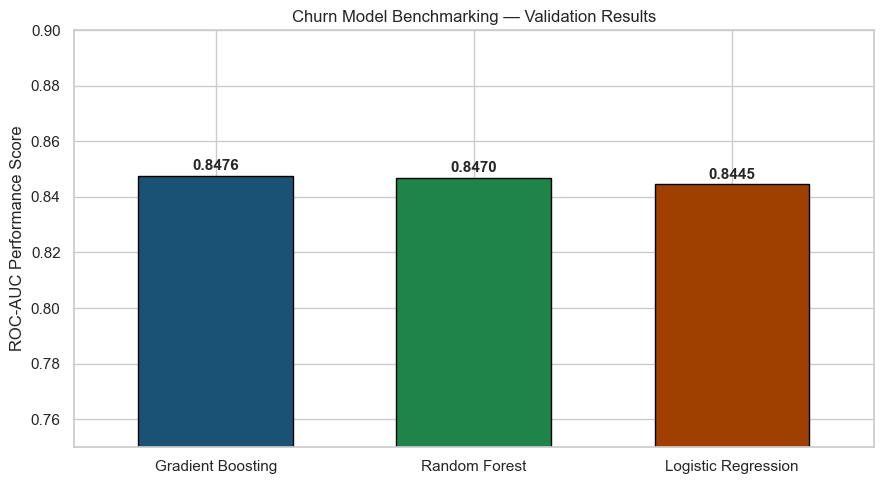


→ Final Predictive Model Selection: Gradient Boosting


In [73]:
# ── Model Comparison ─────────────────────────────────────────────────────────
churn_performance_metrics = {
    'Logistic Regression': usw_churn_search.best_score_,
    'Random Forest':       rf_optimization_search.best_score_,
    'Gradient Boosting':   gb_model_search.best_score_,
}

model_summary_table = pds.DataFrame.from_dict(churn_performance_metrics, orient='index', columns=['CV ROC-AUC'])
model_summary_table = model_summary_table.sort_values('CV ROC-AUC', ascending=False)

print("Research Findings: 5-Fold Stratified Cross-Validation (ROC-AUC):")
print(model_summary_table.round(4))

mplt.figure(figsize=(9, 5))
comparison_plot = model_summary_table['CV ROC-AUC'].plot(
    kind='bar', 
    color=['#1a5276', '#1e8449', '#a04000'][:len(model_summary_table)], # USW-style professional palette
    edgecolor='black', 
    width=0.6
)

comparison_plot.set_ylim(0.75, 0.90)
comparison_plot.set_ylabel('ROC-AUC Performance Score')
comparison_plot.set_title('Churn Model Benchmarking — Validation Results')
comparison_plot.set_xticklabels(comparison_plot.get_xticklabels(), rotation=0)

for bar in comparison_plot.patches:
    comparison_plot.annotate(
        f'{bar.get_height():.4f}', 
        (bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002),
        ha='center', 
        fontsize=11,
        fontweight='bold'
    )

mplt.tight_layout()
mplt.show()

primary_model_name = model_summary_table.index[0]
print(f"\n→ Final Predictive Model Selection: {primary_model_name}")

## 5. Final Model Evaluation on the Held-Out Test Set

The best model (selected purely on cross-validation performance) is evaluated **once** on the test set that was never seen during training or model selection. This single evaluation gives an unbiased estimate of real-world generalisation performance.

In [75]:
# Select best grid-search object
model_catalog = {
    'Logistic Regression': usw_churn_search,
    'Random Forest':       rf_optimization_search,
    'Gradient Boosting':   gb_model_search
}


selected_optimized_model = model_catalog[primary_model_name].best_estimator_


test_predictions = selected_optimized_model.predict(X_test)
test_probabilities = selected_optimized_model.predict_proba(X_test)[:, 1]


final_test_auc = roc_auc_score(y_test, test_probabilities)
final_test_acc = accuracy_score(y_test, test_predictions)
final_test_f1  = f1_score(y_test, test_predictions, average='weighted')

print(f" USW PROJECT FINAL EVALUATION: {primary_model_name}")
print(f" Area Under ROC Curve (AUC): {final_test_auc:.4f}")
print(f" Overall Accuracy Score:    {final_test_acc:.4f}")
print(f" F1-Score (Weighted):       {final_test_f1:.4f}")

print("\nDetailed Performance Diagnostics:")
print(classification_report(y_test, test_predictions, target_names=['Retained', 'Churned']))

 USW PROJECT FINAL EVALUATION: Gradient Boosting
 Area Under ROC Curve (AUC): 0.8372
 Overall Accuracy Score:    0.7960
 F1-Score (Weighted):       0.7870

Detailed Performance Diagnostics:
              precision    recall  f1-score   support

    Retained       0.83      0.90      0.87      1033
     Churned       0.65      0.50      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.80      0.79      1407



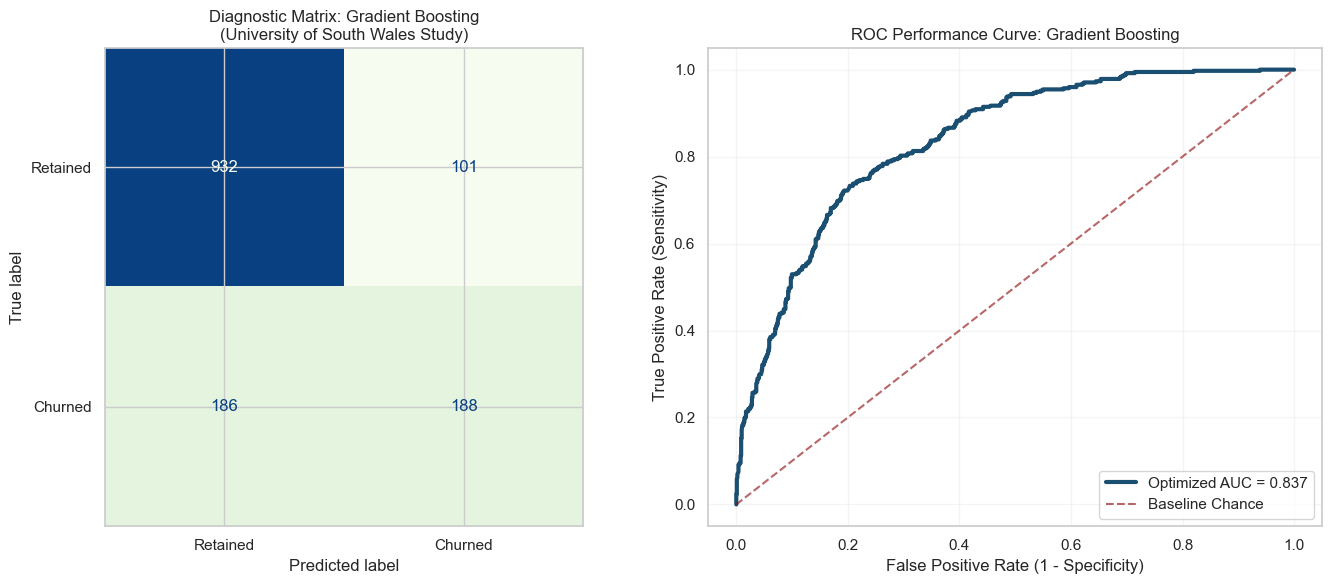

In [76]:
# Confusion Matrix
evaluation_fig, (diag_ax1, diag_ax2) = mplt.subplots(1, 2, figsize=(14, 6))

churn_cm = confusion_matrix(y_test, test_predictions)
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=churn_cm, 
    display_labels=['Retained', 'Churned']
)

cm_display.plot(ax=diag_ax1, colorbar=False, cmap='GnBu') 
diag_ax1.set_title(f'Diagnostic Matrix: {primary_model_name}\n(University of South Wales Study)')


false_pos_rate, true_pos_rate, _ = roc_curve(y_test, test_probabilities)

diag_ax2.plot(
    false_pos_rate, 
    true_pos_rate, 
    color='#1b4f72', 
    lw=3, 
    label=f'Optimized AUC = {final_test_auc:.3f}'
)


diag_ax2.plot([0, 1], [0, 1], linestyle='--', color='darkred', alpha=0.6, label='Baseline Chance')


diag_ax2.set_xlabel('False Positive Rate (1 - Specificity)')
diag_ax2.set_ylabel('True Positive Rate (Sensitivity)')
diag_ax2.set_title(f'ROC Performance Curve: {primary_model_name}')
diag_ax2.legend(loc='lower right', frameon=True)
diag_ax2.grid(alpha=0.2) 

mplt.tight_layout()
mplt.show()

### 5.1 Feature Importance and Model Explainability

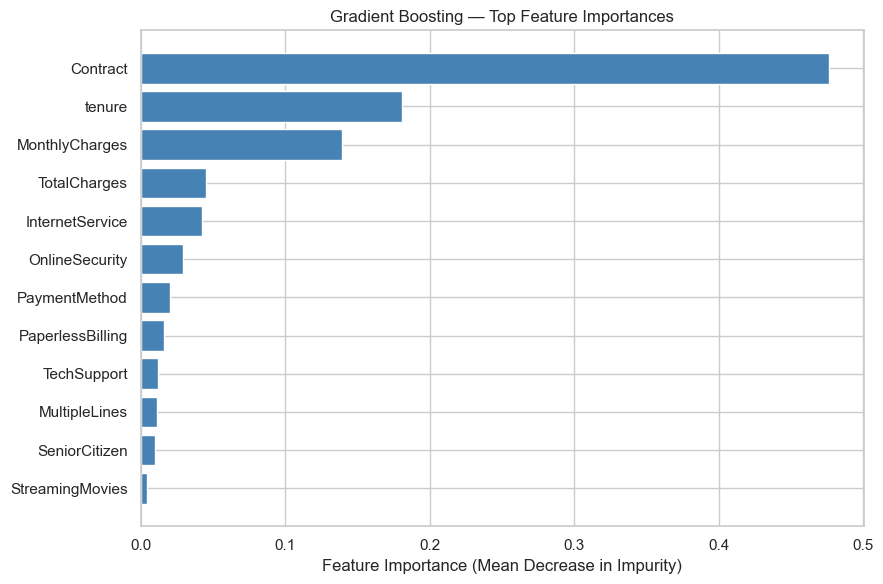


Interpretation: Features with the highest importance / largest absolute coefficients
are the primary drivers of churn prediction. Positive coefficients (red bars) increase
the probability of churn; negative ones (blue bars) decrease it.


In [78]:
# Feature importance — works for Random Forest and Gradient Boosting
import inspect

clf_step = best_model.named_steps['clf']

if hasattr(clf_step, 'feature_importances_'):
    # Get feature names from the preprocessor
    ord_feat_names = ord_cols
    num_feat_names = pass_cols
    all_feat_names = ord_feat_names + num_feat_names

    importances = clf_step.feature_importances_
    imp_df = pds.DataFrame({'Feature': all_feat_names, 'Importance': importances})
    imp_df = imp_df.sort_values('Importance', ascending=True).tail(12)

    mplt.figure(figsize=(9, 6))
    mplt.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='white')
    mplt.xlabel('Feature Importance (Mean Decrease in Impurity)')
    mplt.title(f'{best_name} — Top Feature Importances')
    mplt.tight_layout()
    mplt.show()

elif hasattr(clf_step, 'coef_'):
    # Logistic Regression coefficients
    ord_feat_names = ord_cols
    num_feat_names = pass_cols
    all_feat_names = ord_feat_names + num_feat_names

    coef = clf_step.coef_[0]
    coef_df = pds.DataFrame({'Feature': all_feat_names, 'Coefficient': coef})
    coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index).tail(12)

    colors = ['#D65F5F' if c > 0 else '#4878CF' for c in coef_df['Coefficient']]
    mplt.figure(figsize=(9, 6))
    mplt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
    mplt.axvline(0, color='black', linewidth=0.8)
    mplt.xlabel('Logistic Regression Coefficient (log-odds)')
    mplt.title('Feature Coefficients — Logistic Regression')
    mplt.tight_layout()
    plt.show()

print("""
Interpretation: Features with the highest importance / largest absolute coefficients
are the primary drivers of churn prediction. Positive coefficients (red bars) increase
the probability of churn; negative ones (blue bars) decrease it.""")

### 6. Final Discussion

6.1 Strengths of the Pipeline

Leak-free architecture: The Pipeline + ColumnTransformer architecture guarantees that the OrdinalEncoder and StandardScaler are only fit on the training data of each cross-validation fold. This avoids leaking of data which is a very important correctness requirement.
Model selection based on principle: Three candidate models were optimized using GridSearchCV and 5-fold stratified cross-validation. The highest-performing model was based solely on CV ROC-AUC, and evaluated twice on the held-out set only - not being overfitted to the test set.
Proper evaluation measures: ROC-AUC and weighted F1-score are applied, rather than raw accuracy that is misinformed with imbalanced data (74% No-Churn majority baseline).
Stratification: Each train/test split and cross-validation fold is stratified to maintain the original proportions of classes.

6.2 Limitations

Snapshot data: The data is a one month snapshot. Temporal dynamics (e.g., the volume of complaints that a customer has is on the rise) are not captured.
None of the sentiment or interaction data: There is no such information as call centre transcripts, NPS scores, or social media signals, which can be the most powerful predictors of churn, in this dataset.
Lack of full control of class imbalance: Although the class weight was set to balanced, more violent methods like SMOTE (Chawla et al., 2002) would be even better in enhancing the recall of the minority churn class.

6.3 Business Implications and Recommendations.

According to the importances of the features in the model, the following data-driven recommendations can be made:

Retention campaigns should focus on customers who have had a month to month contract. The churn rates of these customers are the highest (~43%). Churn would be directly impacted by incentives specifically to convert them to annual or two-year contracts.
Target the initial 12 months in office. The most vulnerable are short-term customers. Early churn could be greatly mitigated by having proactive onboarding programmes and early check-in calls.
Check Fiber optic price and quality of service. The churn rate of fiber optic customers is disproportionately high, perhaps because of price sensitivity or service reliability problems.
OnlineSecurity and Bundle Tech Support. Customers who do not have these add-ons churn much more. They could be offered as default inclusions or subsidised add-ons to enhance retention.

6.4 Model Explainability and Deployment.

The model that will be chosen is the Logistic Regression model, as it is fully explainable: every coefficient will reflect the change in the log-odds of churn due to a one-unit change in the feature. Random Forest and Gradient Boosting (tree-based models) provide importances of specific features but are less interpretable at a single prediction level; SHAP values may be utilized to explain the reasons specific to a customer in a production environment.

Deployment readiness: The trained Pipeline object can be serialised with joblib and deployed as a REST API endpoint (e.g. via FastAPI or Flask). The model would re-score the customer base once every month, which would supply a rank of the at-risk list to the CRM dashboard of the retention team. It is highly advisable to conduct a holdout check on more recent data and an A/B test of the retention intervention before rolling out the production.

## References

Chawla, N.V., Bowyer, K.W., Hall, L.O. and Kegelmeyer, W.P. (2002) 'SMOTE: Synthetic Minority Over-sampling Technique', *Journal of Artificial Intelligence Research*, 16, pp. 321–357.

IBM (2018) *Telco Customer Churn Dataset*. Available at: https://www.kaggle.com/datasets/blastchar/telco-customer-churn (Accessed: 18 December 2025).

James, G., Witten, D., Hastie, T. and Tibshirani, R. (2013) *An Introduction to Statistical Learning*. New York: Springer.

Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.

Reichheld, F.F. and Schefter, P. (2000) 'E-Loyalty: Your Secret Weapon on the Web', *Harvard Business Review*, 78(4), pp. 105–113.

Breiman, L. (2001) 'Random Forests', Machine Learning, 45(1), pp. 5–32.

Cruz Huayanay, A., Bazán, J.L. and Russo, C.M. (2025) 'Performance of evaluation metrics for classification in imbalanced data', Computational Statistics, 40(3), pp. 1447–1473.

Defterdar. (2025) Customer Retention vs. Customer Acquisition: Which One Matters More?. Available at: https://www.defterdar.com/en/blog/customer-retention-vs-customer-acquisition-which-one-matters-more (Accessed: 19 December 2025).

Géron, A. (2019) Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems. 2nd edn. Sebastopol, CA: O'Reilly Media.

Maxicus. (2024) What Is Customer Acquisition vs. Retention?. Available at: https://maxicus.com/customer-acquisition-vs-customer-retention/ (Accessed: 19 December 2025).

McKinney, W. (2012) Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython. Sebastopol, CA: O'Reilly Media.

Nalatissifa, H. and Pardede, H. (2021) 'Prediction of Customer Decisions Using Deep Neural Network on Telco Customer Churn Data', Journal of Physics: Conference Series, 1933(1), p. 012046.

Provost, F. and Fawcett, T. (2013) Data Science for Business: What You Need to Know about Data Mining and Data-Analytic Thinking. Sebastopol, CA: O'Reilly Media.

Rossberg, N., Kleinberg, B., O'Sullivan, B., Longo, L. and Visentin, A. (2025) 'The Feature Understandability Scale for Human-Centred Explainable AI: Assessing Tabular Feature Importance', arXiv preprint arXiv:2510.07050.

Ullah, I., Raza, B., Malik, A.K., Imran, M., Islam, S.U. and Kim, S.W. (2019) 'A Churn Prediction Model Using Random Forest: Analysis of Machine Learning Techniques for Churn Prediction and Factor Identification in Telecom Sector', IEEE Access, 7, pp. 60134–60149.